# Large-Scale Dataset Analysis: 250K Job Records

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('../Dataset/original_dataset.csv')

This dataset is under Creative Commons CC0 (Public Domain Dedication).

## I. Data cleaning, memory optimization and validation

In [3]:
df.head(10)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
5,AI Engineer,0,High School,4,Education,Enterprise,USA,No,2,180351
6,Backend Developer,6,High School,16,Manufacturing,Enterprise,Canada,No,3,165375
7,Machine Learning Engineer,4,Bachelor,18,Healthcare,Enterprise,Canada,Hybrid,5,202463
8,AI Engineer,5,Diploma,14,Telecom,Enterprise,Singapore,Yes,0,171834
9,Frontend Developer,18,PhD,2,Retail,Enterprise,India,Hybrid,5,128377


In the previous cell, we used `df.head(10)` to display the first 10 rows of the DataFrame.
This allows us to quickly inspect the structure of the data.

### I-1. 📊 Data Structure & Technical Audit

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   job_title         250000 non-null  str  
 1   experience_years  250000 non-null  int64
 2   education_level   250000 non-null  str  
 3   skills_count      250000 non-null  int64
 4   industry          250000 non-null  str  
 5   company_size      250000 non-null  str  
 6   location          250000 non-null  str  
 7   remote_work       250000 non-null  str  
 8   certifications    250000 non-null  int64
 9   salary            250000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 30.7 MB


A technical inspection of the 250,000 records using df.info() reveals the following:

- Data Integrity  
  The dataset is fully complete with no missing values, meaning no imputation is required at this stage.

- Feature Types  
  The dataset includes 4 numerical columns (e.g., salary, experience_years) correctly stored as int64, and 6 categorical columns currently represented as strings.

- Memory Optimization  
  The dataset currently uses approximately 30.7 MB of memory.  
  To improve efficiency, high-frequency string columns such as industry, education_level, and remote_work will be converted to the category data type, reducing memory usage.

### I-2. 🔍 Categorical Values Validation (Data Integrity Check)

In [5]:
text_cols = df.select_dtypes(include=['object', 'str']).columns
for col in text_cols:
    print(f"--- Unique values in {col} ---")
    print(df[col].unique())
    print("\n")

--- Unique values in job_title ---
<ArrowStringArray>
[              'AI Engineer',              'Data Analyst',
        'Frontend Developer',          'Business Analyst',
           'Product Manager',         'Backend Developer',
 'Machine Learning Engineer',           'DevOps Engineer',
         'Software Engineer',     'Cybersecurity Analyst',
            'Data Scientist',            'Cloud Engineer']
Length: 12, dtype: str


--- Unique values in education_level ---
<ArrowStringArray>
['Bachelor', 'PhD', 'High School', 'Diploma', 'Master']
Length: 5, dtype: str


--- Unique values in industry ---
<ArrowStringArray>
[   'Healthcare',       'Telecom',         'Media',        'Retail',
 'Manufacturing',     'Education',       'Finance',    'Technology',
    'Consulting',    'Government']
Length: 10, dtype: str


--- Unique values in company_size ---
<ArrowStringArray>
['Medium', 'Small', 'Large', 'Enterprise', 'Startup']
Length: 5, dtype: str


--- Unique values in location ---
<ArrowS

After performing a deep dive into the unique values of each categorical column, we have verified the following:
1. Data Consistency & Cleaning Quality

    No Redundancy: There are no duplicate categories written in different styles (e.g., "Remote" and "remote" are not present; only one consistent format exists).

    No Whitespace Issues: All string values are "trimmed" and clean; there are no leading or trailing spaces 


    Status: ✅ Production-Ready

    Conclusion: Everything is perfectly aligned. The categories are logical, standardized, and clean, providing a robust foundation for the next stage of statistical analysis and visualization.

### I-3. 📈 Statistical Summary & Sanity Check

In [6]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


By analyzing the descriptive statistics of the numerical features, we can confirm the logical integrity of the dataset:
For example :Salary Distribution (The "Pay" Logic)

    Range: The salaries range from $31,867 (Min) to $333,046 (Max).

    Status: ✅ Logically Sound

    Conclusion: All numerical ranges are within realistic bounds. There are no "Impossible" values (e.g., negative salaries, 1000 years of experience, or millions of certifications). The data is statistically consistent and ready for deeper exploration.

### I-4. 💾 Initial Memory Consumption (Pre-Optimization)

In [7]:
print(df.memory_usage(deep=True))

Index                   132
job_title           6061551
experience_years    2000000
education_level     3750430
skills_count        2000000
industry            4174893
company_size        3648620
location            3600551
remote_work         2916807
certifications      2000000
salary              2000000
dtype: int64



Before applying any data type transitions, we inspected the memory footprint of the DataFrame using df.memory_usage(deep=True).
1. Analysis of Current State

    Heavyweight Columns: The text-based columns (stored as object) are consuming the most memory. For example:

        job_title: ~6.06 MB

        industry: ~4.17 MB

        education_level: ~3.75 MB


2. Technical Observation

    Status: ⚠️ Pre-Optimization Phase

    Issue: Storing repetitive strings as "Objects" is inefficient. Each entry is being stored as a full string pointer, which scales poorly as the dataset grows.

    Observation: The total memory usage is dominated by these categorical strings, which are prime candidates for optimization.

3. Transition Goal

This baseline measurement serves as our Control Group. In the next step, we will convert these 6 string columns to the category type to observe the drastic reduction in memory overhead.

### I-5. ⚙️ Data Type Transformation (Memory Optimization)

In [8]:
df['job_title'] = df['job_title'].astype('category')
df['education_level'] = df['education_level'].astype('category')
df['industry'] = df['industry'].astype('category')
df['company_size'] = df['company_size'].astype('category')
df['location'] = df['location'].astype('category')
df['remote_work'] = df['remote_work'].astype('category')


In this step, we executed a strategic conversion of categorical features to enhance performance and reduce memory overhead.
1. The Engineering Action

We identified 6 columns originally stored as generic Strings (Objects) and explicitly cast them to the category data type:

    job_title, education_level, industry, company_size, location, and remote_work.

2. Why Category over String?

    Storage Efficiency: Instead of storing the full text for each of the 250,000 rows, Pandas now stores a unique integer key for each category, mapping it to the original string in a small lookup table.

    Computational Speed: Operations such as sorting, grouping, and unique value counting are now significantly faster as they operate on integers "under the hood."


In [9]:
print(df.memory_usage(deep=True))

Index                   132
job_title            250293
experience_years    2000000
education_level      250076
skills_count        2000000
industry             250169
company_size         250074
location             250146
remote_work          250036
certifications      2000000
salary              2000000
dtype: int64


 Status: ✅ Optimized

    Result: The data remains logically identical, but the internal representation is now optimized for large-scale data analysis and machine learning workflows.

In [10]:
df.to_parquet('jobs_data_optimized.parquet')

After optimizing the data types and verifying the integrity of the 250,000 records, we exported the final DataFrame to a Parquet file format.

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   job_title         250000 non-null  category
 1   experience_years  250000 non-null  int64   
 2   education_level   250000 non-null  category
 3   skills_count      250000 non-null  int64   
 4   industry          250000 non-null  category
 5   company_size      250000 non-null  category
 6   location          250000 non-null  category
 7   remote_work       250000 non-null  category
 8   certifications    250000 non-null  int64   
 9   salary            250000 non-null  int64   
dtypes: category(6), int64(4)
memory usage: 9.1 MB


### I-6. 📉  Optimization Results (Final Review)



After converting the string-based columns to the category data type, we re-inspected the DataFrame structure to quantify the performance gains.
1. Key Observations

    Data Type Update: All 6 target columns (job_title, education_level, etc.) are now successfully recognized as category instead of object.

2. Memory Usage Impact

    Initial Memory: ~30.7 MB

    Optimized Memory: 9.1 MB

    Efficiency Gain: We achieved a ~70% reduction in memory footprint.

3. Why this matters for Scalability

By reducing the memory usage to less than a third of its original size, we have:

    Faster Computations: Operations like df.groupby() or df.pivot_table() will now run much faster because they process integer codes instead of raw strings.


## II. Exploratory Data Analysis (EDA)

### II-1. Correlation Analysis: Years of Experience vs. Annual Salary

#### I-1-1. Correlation between Experience Years and Salary

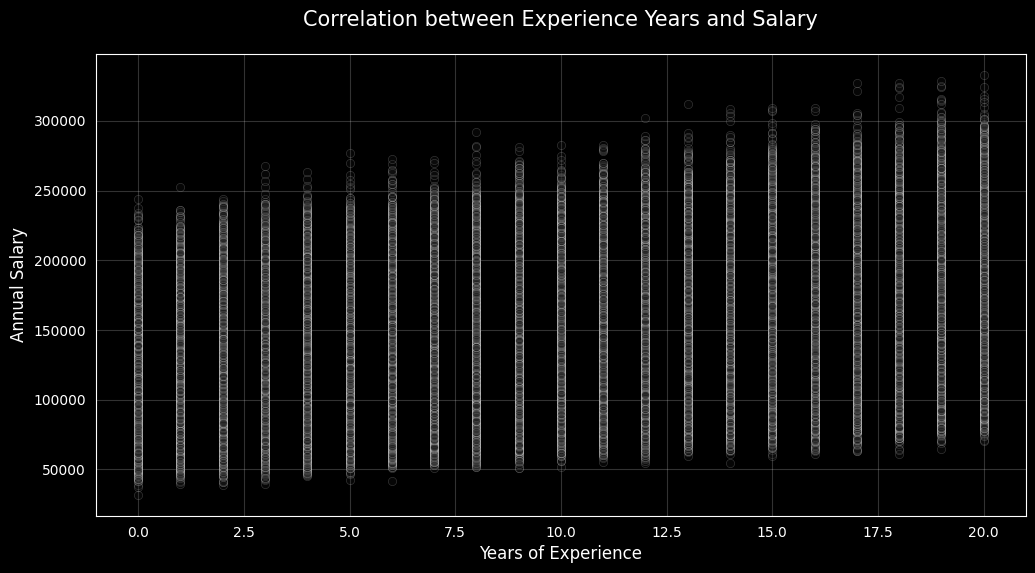

In [41]:
plt.style.use('dark_background')
plt.figure(figsize=(12, 6))

sns.scatterplot(data=df, x='experience_years', y='salary', alpha=0.2, color='#222')

plt.title('Correlation between Experience Years and Salary', fontsize=15, pad=20)
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Annual Salary', fontsize=12)

plt.grid(True, alpha=0.2)
plt.show()

Based on the visualized 250,000 records in Correlation between Experience Years and Salary scatter plot, we can observe the following:

  -  Upward Trend in Max and Min Salaries: There is a clear positive correlation where an increase in Years of Experience leads to a consistent rise in both the Minimum and Maximum salary levels within the dataset.

  -   Shift in Density Concentration: While the overall range expands, we observe that the highest density of points (the darkest areas in the plot) gradually shifts upward as experience increases. This indicates that the "market standard" for a typical salary moves to a higher baseline with seniority.

  -  Salary Overlap: The data shows that certain individuals with fewer years of experience earn higher salaries than others with significantly more seniority, suggesting that other factors (skills or industry) play a major role.

  - Next Step: To gain a clearer understanding of the typical career progression, we will conduct a comparison of Median Salaries across all years of experience in the data.

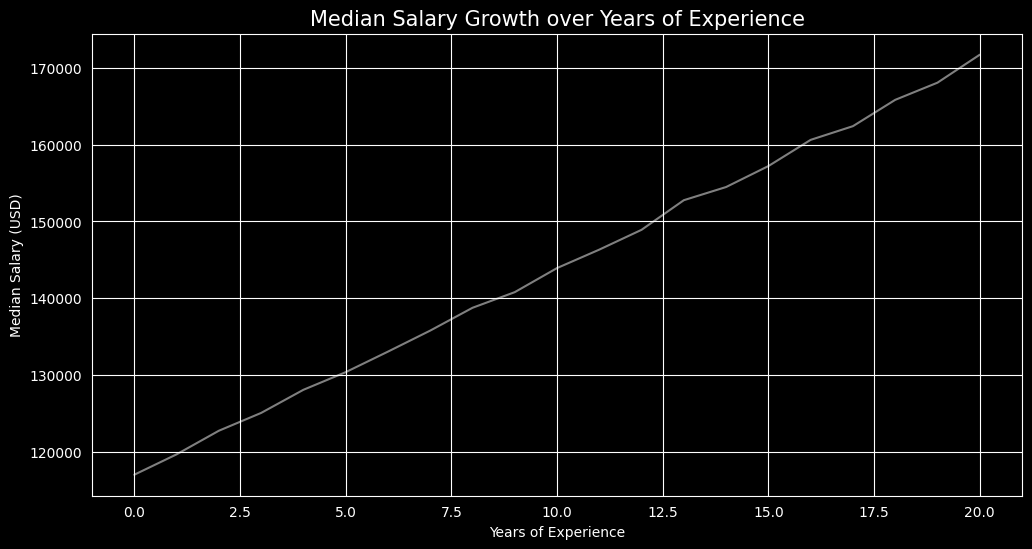

In [30]:

plt.style.use('dark_background')
plt.figure(figsize=(12, 6))

sns.lineplot(data=df, x='experience_years', y='salary', estimator=np.median, errorbar=None, color='#fff', alpha=0.5)

plt.title('Median Salary Growth over Years of Experience', fontsize=15)
plt.xlabel('Years of Experience')
plt.ylabel('Median Salary (USD)')

plt.show()

Based on the Median Salary Growth over Years of Experience plot, we can observe the following:


    Consistent Median Increase: There is a clear and steady upward trend in the median salary as years of experience increase.